# Social Contagion in Networks

In [53]:
from IPython.display import Markdown, display
import nbformat, re

NOTEBOOK_PATH = "project.ipynb"  # <-- set this

def anchor(s):  # GitHub/Jupyter-style anchors
    return re.sub(r'[^0-9a-zA-Z]+', '-', s.strip()).strip('-').lower()

nb = nbformat.read(NOTEBOOK_PATH, as_version=4)

lines = ["# Table of Contents", ""]
for cell in nb.cells:
    if cell.get("cell_type") == "markdown":
        for line in cell["source"].splitlines():
            m = re.match(r'^(#{1,6})\s+(.+?)\s*$', line)
            if not m: 
                continue
            level = len(m.group(1))
            text  = m.group(2).strip()
            lines.append(f'{"  "*(level-1)}- [{text}](#{anchor(text)})')

display(Markdown("\n".join(lines)))


# Table of Contents

- [Social Contagion in Networks](#social-contagion-in-networks)
  - [1. Learning goals](#1-learning-goals)
  - [2. Setup](#2-setup)
  - [3. What is Contagion?](#3-what-is-contagion)
    - [3.1 Real-world examples](#3-1-real-world-examples)
    - [3.2 Why we care](#3-2-why-we-care)
  - [4. Conceptial Overview](#4-conceptial-overview)
    - [4.1 Simple contagion](#4-1-simple-contagion)
    - [4.2 Complex contagion](#4-2-complex-contagion)
  - [5. Models & Implementation](#5-models-implementation)
    - [5.1 Independent Cascade (IC) Model](#5-1-independent-cascade-ic-model)
    - [5.2 Watts Threshold Model (WTM)](#5-2-watts-threshold-model-wtm)
    - [5.3 Six Degrees of Separation Model](#5-3-six-degrees-of-separation-model)
    - [5.4. Your Turn](#5-4-your-turn)
  - [6. How Structure Shapes Cascades](#6-how-structure-shapes-cascades)
    - [6.1. Your Turn](#6-1-your-turn)
    - [6.2 Your Turn](#6-2-your-turn)
  - [7. Thresholds, Heterogeneity, and Adoption Dynamics](#7-thresholds-heterogeneity-and-adoption-dynamics)
  - [8. Temporal Networks and Time-Varying Contagion](#8-temporal-networks-and-time-varying-contagion)
  - [9. Influence Maximization and Seeding Strategies](#9-influence-maximization-and-seeding-strategies)
  - [10. Competing Contagions and Interference](#10-competing-contagions-and-interference)
  - [11. Empirical Data Analysis](#11-empirical-data-analysis)
    - [11.1 Your Turn](#11-1-your-turn)
  - [12. Other Extensions and Advanced Topics:](#12-other-extensions-and-advanced-topics)
    - [12.1 Contagion on Directed/Weighted Networks](#12-1-contagion-on-directed-weighted-networks)
    - [12.2. Contagion Beyond Networks: Spatial, Agent-Based, and Hybrid Models](#12-2-contagion-beyond-networks-spatial-agent-based-and-hybrid-models)
    - [12.3. Advanced Visualization and Animation](#12-3-advanced-visualization-and-animation)
    - [12.4. Social Contagion in LLMs](#12-4-social-contagion-in-llms)
    - [12.5. Causal Identification: Contagion vs Homophily](#12-5-causal-identification-contagion-vs-homophily)
    - [12.6 Multiplex and Multilayer Networks](#12-6-multiplex-and-multilayer-networks)
  - [13. References](#13-references)
  - [14. Useful Links](#14-useful-links)

## 1. Learning goals
- Understand contagion, and why it matters.
- Distinguish between simple and complex contagion.
- Implement canonical models of social contagion.
- Analyze how network structure shapes contagion dynamics.
- Explore strategies for seeding and controlling contagion.
- Connect simulations to analytical insights.
- Extend models to more realistic settings.
- Visualize contagion processes.
- Apply models to empirical data.



## 2. Setup


In [2]:
# Core scientific stack
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from collections import deque
from dataclasses import dataclass
from typing import Callable, Dict, Iterable, List, Optional, Sequence, Tuple, Union, Set

# Reproducibility
rng = np.random.default_rng(42)

# Matplotlib defaults (no explicit color choices per course tooling conventions)
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.grid'] = True

# Helper to silence warnings in demos if needed
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)



## 3. What is Contagion?

**Contagion** refers to the spread of behaviors, ideas, or diseases through networks. It encompasses various processes, including:
- **Epidemics**: Spread of infectious diseases (e.g., flu, COVID-19).
- **Information diffusion**: Spread of news, rumors, or innovations.
- **Behavioral adoption**: Spread of behaviors like smoking, exercise, or technology use.
- **Emotional contagion**: Spread of emotions like happiness or fear.

### 3.1 Real-world examples
Yawning, the spread of panic in a crowd, the adoption of fashion trends, the phenomenon of viral online challenges like the ALS Ice Bucket Challenge, and the rapid dissemination of information (or misinformation) on social media platforms, are all examples of contagion in action.

### 3.2 Why we care
We have a vested interest in understanding contagion because it affects public health, marketing strategies, social movements, and more. By studying contagion, we can design better interventions to promote beneficial behaviors and curb harmful ones. In most social contexts, there are multiple competing contagions (e.g., health behaviors, political ideologies), and policy makers need to understand how to promote or inhibit specific contagions with limited resources.

Also, sometimes, contagion can lead to unintended consequences, such as the spread of misinformation or panic. We need to understand these dynamics to mitigate negative outcomes.

Most of businesses are also interested in understanding contagion to optimize marketing strategies, enhance customer engagement, and drive product adoption. By leveraging insights from contagion models, businesses can create more effective campaigns that resonate with their target audience.

## 4. Conceptial Overview

We can broadly classify contagion processes into two categories: **simple contagion** and **complex contagion**.

### 4.1 Simple contagion
- **Definition**: One effective exposure can trigger adoption.
- **Model**: Independent Cascade (IC) model.
- **Dynamics**: Each newly infected node gets one chance to infect each susceptible neighbor with probability \(p\).
- **Network effects**:
  - Long ties/shortcuts accelerate spread.
  - Clustering can slow spread due to redundant contacts.
  - Degree heterogeneity can create super-spreaders.
- **Applications**: Diseases, information spread, viral marketing.
- **simple contagion**
- Discrete synchronous time steps \(t=0,1,2,...\).
- Newly adopted nodes at time \(t\) get **one chance** to activate each susceptible neighbor with probability \(p\).
- Activated neighbors join at \(t+1\). No de-adoption.
- **Simple contagion**: One *effective* exposure may be sufficient for adoption.  
  Canonical implementations include SI/SIR-style transmission or the **Independent Cascade (IC)** model (discrete-time: each new adopter gets *one* chance to activate each susceptible neighbor with probability p).

- **Newman (2002–2010)**: generating-function analyses of epidemics/percolation; thresholds governed by degree moments.
- **Pastor-Satorras et al. (2015)**: synthesis on epidemic processes and how heterogeneity alters thresholds.


### 4.2 Complex contagion
- **Definition**: Adoption requires multiple exposures or a critical fraction of neighbors adopting.
- **Model**: Watts Threshold Model (WTM).
- **Network effects**:
  - Long ties can hinder spread by bypassing local reinforcement.
  - Clustering/community structure can facilitate spread via repeated exposures.
  - Degree heterogeneity affects cascade likelihood.
- **Applications**: Social movements, technology adoption, behavioral norms.
- **Complex contagion**
- Synchronous updates. Node \(i\) adopts when the adopted-neighbor fraction.
- Thresholds may be constant, drawn from a distribution, or depend on degree.
- Variants: integer \(k\)-thresholds, partial memory windows, weighted edges, multiplex reinforcement.

- **Centola & Macy (2007)**: “weakness of long ties” for behaviors requiring reinforcement.
- **Centola (2010)**: experiments showing clustering promotes behavior adoption.
- **Christakis & Fowler (2007–2013)**: empirical claims of social contagion (health, happiness, obesity, smoking), spurring debates about identification vs. homophily.

**Consequences for networks**
- Long ties and shortcuts **accelerate** simple contagion; they can **hinder** complex contagion by bypassing local reinforcement.
- Clustering/community structure can **delay** simple contagion but **enable** complex contagion via repeated exposures.
- Degree heterogeneity and seeding patterns strongly modulate cascade likelihood in both regimes.


## 5. Models & Implementation

### 5.1 Independent Cascade (IC) Model

In [20]:

@dataclass
class CascadeResult:
    adopted: Set
    history: List[Set]
    adopters_by_t: List[int]
    exposures: Dict # node -> number of received attempts (IC) or neighbor counts (WTM)
    steps: int
def choose_seeds(G: nx.Graph, k: int, method: str = "random", rng: Optional[np.random.Generator] = None) -> List:
    """Pick k seed nodes by a given strategy.
    
    method in {"random", "degree", "kcore"}.
    """
    rng = rng or np.random.default_rng()
    nodes = list(G.nodes())
    if k <= 0:
        return []
    if method == "random":
        return list(rng.choice(nodes, size=min(k, len(nodes)), replace=False))
    elif method == "degree":
        return [n for n,_ in sorted(G.degree(), key=lambda t: t[1], reverse=True)[:k]]
    elif method == "kcore":
        kc = nx.core_number(G)
        return [n for n,_ in sorted(kc.items(), key=lambda t: t[1], reverse=True)[:k]]
    else:
        raise ValueError(f"Unknown seeding method: {method}")


In [21]:

def simulate_ic(
    G: nx.Graph,
    seeds: Iterable,
    p: float = 0.1,
    max_steps: Optional[int] = None,
    rng: Optional[np.random.Generator] = None,
) -> CascadeResult:
    """Independent Cascade (IC) model.
    
    Parameters
    ----------
    G : nx.Graph
    seeds : iterable of seed nodes
    p : float in [0,1], activation prob along each edge (one attempt per newly adopted neighbor)
    max_steps : optional step cap
    rng : numpy Generator
    
    Returns
    -------
    CascadeResult with adopted set, history (set per t), adopters_by_t (counts), exposures, steps
    """
    rng = rng or np.random.default_rng()
    adopted = set(seeds)
    frontier = set(seeds)  # newly adopted at current t
    history = [set(frontier)]
    adopters_by_t = [len(frontier)]
    exposures = {n: 0 for n in G.nodes()}  # number of *attempts* received
    
    steps = 0
    while frontier and (max_steps is None or steps < max_steps):
        steps += 1
        new_frontier = set()
        for u in frontier:
            for v in G.neighbors(u):
                if v in adopted:
                    continue
                exposures[v] = exposures.get(v, 0) + 1
                if rng.random() < p:
                    adopted.add(v)
                    new_frontier.add(v)
        if not new_frontier:
            break
        history.append(set(new_frontier))
        adopters_by_t.append(len(new_frontier))
        frontier = new_frontier
    return CascadeResult(adopted=adopted, history=history, adopters_by_t=adopters_by_t, exposures=exposures, steps=steps)


### 5.2 Watts Threshold Model (WTM)

In [22]:

def _resolve_thresholds(G: nx.Graph, phi: Union[float, Dict, Callable, Sequence], rng: Optional[np.random.Generator] = None) -> Dict:
    """Return dict of node->threshold in [0,1].
    - float: constant
    - dict: per-node
    - callable: called per node to sample threshold
    - sequence: aligned in order of G.nodes()
    """
    rng = rng or np.random.default_rng()
    nodes = list(G.nodes())
    if isinstance(phi, (float, int)):
        return {n: float(phi) for n in nodes}
    if isinstance(phi, dict):
        # default to 1.1 (impossible) if missing, ensuring explicitness
        return {n: float(phi.get(n, 1.1)) for n in nodes}
    if callable(phi):
        return {n: float(phi(n, G, rng)) for n in nodes}
    # sequence-like
    arr = list(map(float, phi))
    if len(arr) != len(nodes):
        raise ValueError("Length of phi sequence must equal number of nodes")
    return {n: arr[i] for i, n in enumerate(nodes)}

def simulate_wtm(
    G: nx.Graph,
    seeds: Iterable,
    phi: Union[float, Dict, Callable, Sequence] = 0.2,
    synchronous: bool = True,
    max_steps: Optional[int] = None,
    rng: Optional[np.random.Generator] = None,
) -> CascadeResult:
    """Watts Threshold Model (WTM) / fractional threshold complex contagion.
    
    Parameters
    ----------
    G : nx.Graph
    seeds : iterable of seed nodes
    phi : threshold spec (float, dict, callable, or sequence). Fraction of neighbors required.
    synchronous : if True, update in rounds; otherwise adopt as soon as threshold satisfied in a wave
    max_steps : optional step cap
    rng : numpy Generator
    """
    rng = rng or np.random.default_rng()
    thresholds = _resolve_thresholds(G, phi, rng=rng)
    adopted = set(seeds)
    history = [set(adopted)]
    adopters_by_t = [len(adopted)]
    steps = 0
    # track neighbor counts for introspection
    exposures = {n: 0 for n in G.nodes()}  # here we store current number of adopted neighbors
    
    def fraction_adopted_neighbors(v):
        k = G.degree(v)
        if k == 0:
            return 0.0
        a = sum((1 for u in G.neighbors(v) if u in adopted))
        exposures[v] = a  # store raw count
        return a / k
    
    while True and (max_steps is None or steps < max_steps):
        steps += 1
        if synchronous:
            new_adopters = {v for v in G.nodes() if v not in adopted and fraction_adopted_neighbors(v) >= thresholds[v]}
        else:
            # asynchronous "wave": scan in random order
            new_adopters = set()
            for v in rng.permutation(list(G.nodes())):
                if v in adopted or v in new_adopters:
                    continue
                if fraction_adopted_neighbors(v) >= thresholds[v]:
                    new_adopters.add(v)
                    adopted.add(v)  # immediate reinforcement effect
        if not new_adopters:
            break
        adopted |= new_adopters
        history.append(set(new_adopters))
        adopters_by_t.append(len(new_adopters))
    return CascadeResult(adopted=adopted, history=history, adopters_by_t=adopters_by_t, exposures=exposures, steps=steps)


In [23]:

def make_graph(kind: str = "ER", n: int = 200, avg_k: float = 6, rng: Optional[np.random.Generator] = None) -> nx.Graph:
    """Convenience graph factory for demos: ER, WS, BA.
    avg_k is interpreted per model.
    """
    rng = rng or np.random.default_rng()
    if kind.upper() == "ER":
        p = avg_k / (n-1)
        return nx.erdos_renyi_graph(n, p, seed=rng)
    if kind.upper() == "WS":
        k = int(round(avg_k))
        k = k + (k % 2)  # ensure even
        # beta (rewiring prob) exposed in wrapper below
        return nx.watts_strogatz_graph(n, k, 0.1, seed=rng)  # default beta=0.1
    if kind.upper() == "BA":
        m = max(1, int(round(avg_k/2)))
        return nx.barabasi_albert_graph(n, m, seed=rng)
    raise ValueError("kind must be one of {'ER','WS','BA'}")

def run_many_ic(G, seeds, ps: Sequence[float], runs_per_p: int = 20, rng: Optional[np.random.Generator] = None) -> pd.DataFrame:
    rng = rng or np.random.default_rng()
    rows = []
    for p in ps:
        for r in range(runs_per_p):
            res = simulate_ic(G, seeds=seeds, p=p, rng=rng)
            rows.append(dict(model="IC", p=p, run=r, final_frac=len(res.adopted)/G.number_of_nodes(), steps=res.steps))
    return pd.DataFrame(rows)

def run_many_wtm(G, seeds, phis: Sequence[float], runs_per_phi: int = 1, rng: Optional[np.random.Generator] = None) -> pd.DataFrame:
    rng = rng or np.random.default_rng()
    rows = []
    for phi in phis:
        for r in range(runs_per_phi):
            res = simulate_wtm(G, seeds=seeds, phi=phi, rng=rng)
            rows.append(dict(model="WTM", phi=phi, run=r, final_frac=len(res.adopted)/G.number_of_nodes(), steps=res.steps))
    return pd.DataFrame(rows)

def plot_sweep(df: pd.DataFrame, x: str, y: str = "final_frac", xlabel: str = "", ylabel: str = "Final adoption"):
    ax = df.groupby(x)[y].mean().plot(marker="o", lw=1)
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0,1)
    plt.show()


IC: final adoption 11/200 in 4 steps
WTM: final adoption 200/200 in 9 steps


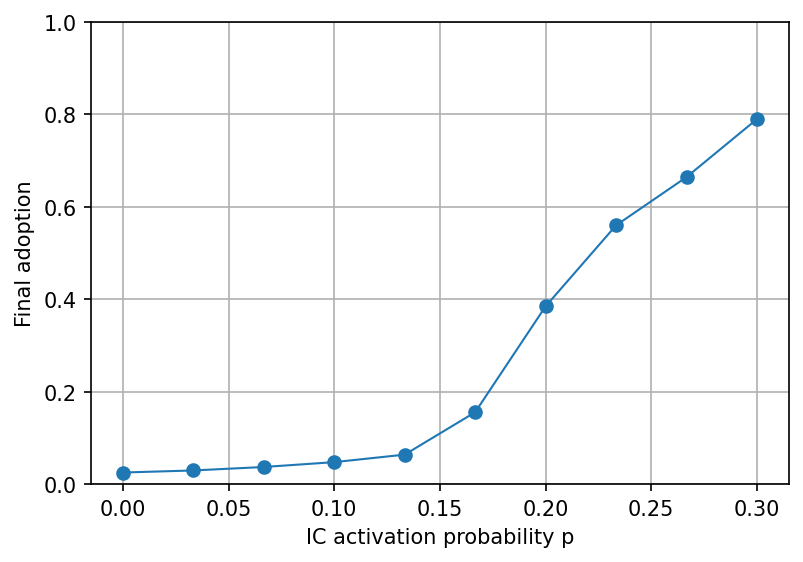

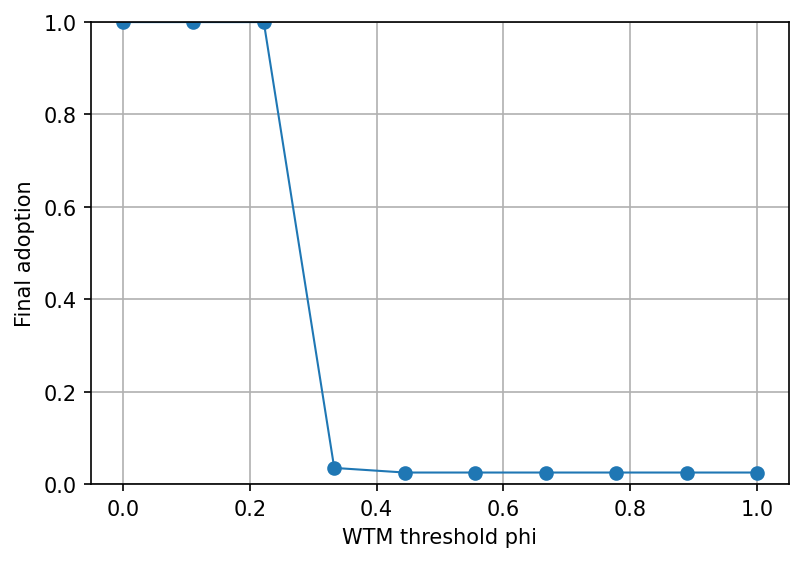

In [11]:
# run codes above

# Example usage
G = make_graph("ER", n=200, avg_k=6, rng=rng)
seeds = choose_seeds(G, k=5, method="random", rng=rng)
ic_res = simulate_ic(G, seeds=seeds, p=0.1, rng=rng)
wtm_res = simulate_wtm(G, seeds=seeds, phi=0.2, rng=rng)

# compare results
print(f"IC: final adoption {len(ic_res.adopted)}/{G.number_of_nodes()} in {ic_res.steps} steps")
print(f"WTM: final adoption {len(wtm_res.adopted)}/{G.number_of_nodes()} in {wtm_res.steps} steps")

# plot them using plot_sweep function above
ps = np.linspace(0, 0.3, 10)
phis = np.linspace(0, 1.0, 10)
ic_df = run_many_ic(G, seeds, ps, runs_per_p=20, rng=rng)
wtm_df = run_many_wtm(G, seeds, phis, runs_per_phi=5, rng=rng)
combined_df = pd.concat([ic_df, wtm_df], ignore_index=True)
plot_sweep(combined_df[combined_df['model'] == 'IC'], x='p', xlabel='IC activation probability p')
plot_sweep(combined_df[combined_df['model'] == 'WTM'], x='phi', xlabel='WTM threshold phi')


### 5.3 Six Degrees of Separation Model

**Six degrees & small worlds**
- **Milgram (1967)**: surprisingly short social chains; popularized as “six degrees of separation.”
- **Watts & Strogatz (1998)**: **small-world networks** exhibit high clustering \(C\) with low average path length \(L\).  
  **Implication**: rapid reach with locally dense neighborhoods => key for reinforcement dynamics.


We quantify **average path length** \(L\) and **clustering** \(C\) across regimes, then visualize the distribution of geodesic distances to connect with the “six degrees” intuition.

In [24]:
# get subgraph of largest connected component
def largest_cc_subgraph(G: nx.Graph) -> nx.Graph:
    if nx.is_connected(G):
        return G
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        return G.subgraph(largest_cc).copy()
    
def ws_graph(n=300, k=6, beta=0.05, seed=None):
    k = k + (k % 2)
    return nx.watts_strogatz_graph(n, k, beta, seed=seed)

def summarize_graph(G: nx.Graph):
    return nx.average_shortest_path_length(G), nx.average_clustering(G)

def path_length_hist(G: nx.Graph, bins=None, samples=4000, rng=None):
    rng = rng or np.random.default_rng()
    nodes = list(G.nodes())
    m = min(samples, len(nodes)*(len(nodes)-1)//2)
    pairs = [(rng.integers(0, len(nodes)), rng.integers(0, len(nodes))) for _ in range(m)]
    dists = []
    for i,j in pairs:
        if i == j: 
            continue
        try:
            dists.append(nx.shortest_path_length(G, nodes[i], nodes[j]))
        except nx.NetworkXNoPath:
            pass
    if not dists:
        return
    if bins is None:
        bins = np.arange(0, max(dists)+2)
    plt.hist(dists, bins=bins, density=True)
    plt.xlabel("Shortest-path length")
    plt.ylabel("Density")
    plt.title("Geodesic length distribution")
    plt.show()

Gs = {
    "Lattice-like (β=0)":   ws_graph(n=1000, k=6, beta=0.0, seed=rng),
    "Small-world (β=0.1)": ws_graph(n=1000, k=6, beta=0.1, seed=rng),
    "Random-like (β=1)":    ws_graph(n=1000, k=6, beta=1.0, seed=rng),
    # connected random graph with same n, m; make sure it's connected
    "Erdős-Rényi (p=0.024)": largest_cc_subgraph(nx.erdos_renyi_graph(n=1000, p=6/999, seed=rng, directed=False))
}

rows = []
for name, G in Gs.items():
    L, C = summarize_graph(G)
    rows.append(dict(model=name, L=L, C=C))
pd.DataFrame(rows)


,model,L,C
0,Lattice-like (β=0),83.750751,0.600000
1,Small-world (β=0.1),6.248420,0.451831
2,Random-like (β=1),4.100200,0.005282
3,Erdős-Rényi (p=0.024),4.106546,0.005635


Small-world (β=0.1):


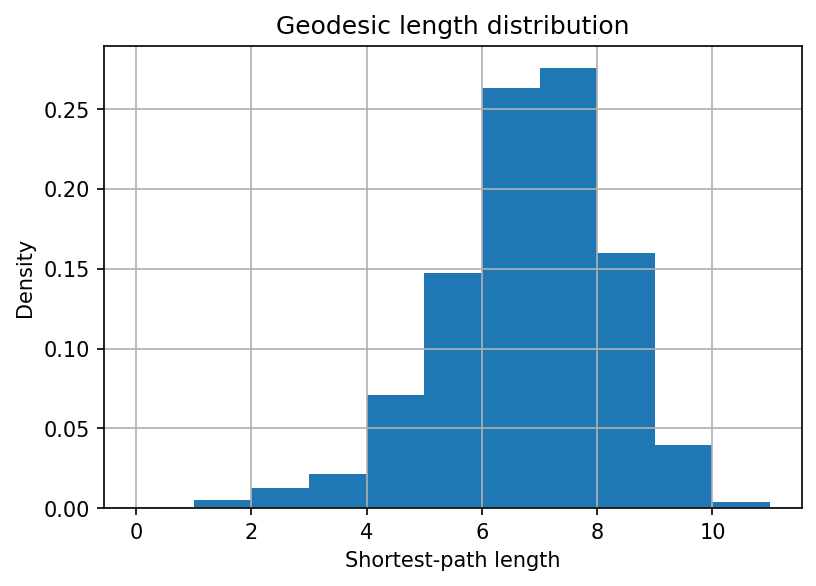

Lattice-like (β=0):


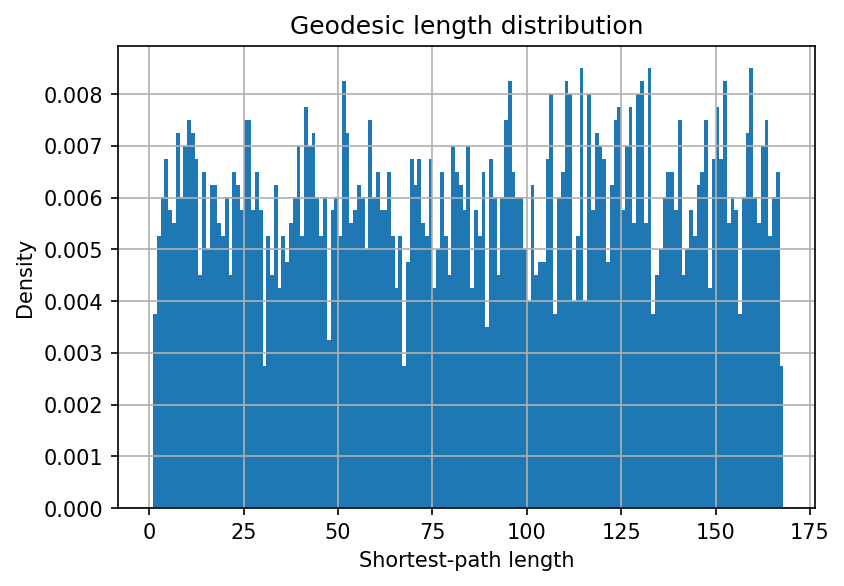

Random-like (β=1):


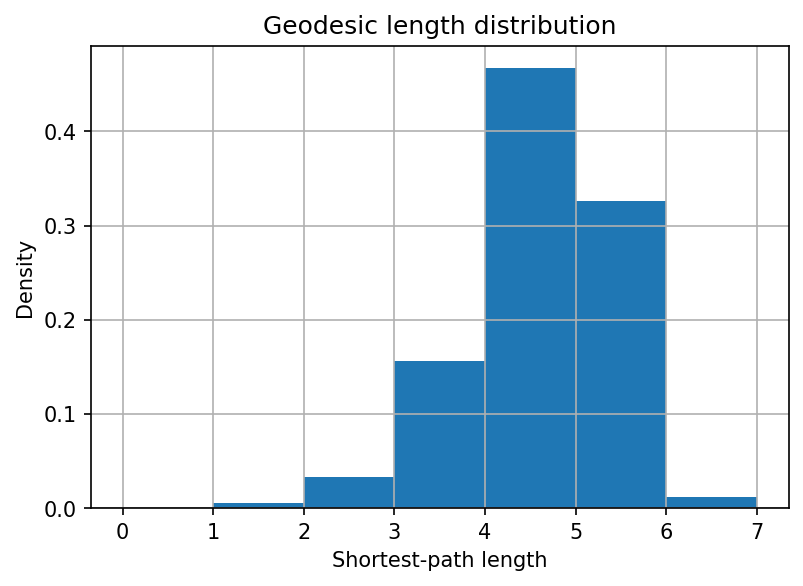

Erdős-Rényi (p=0.024):


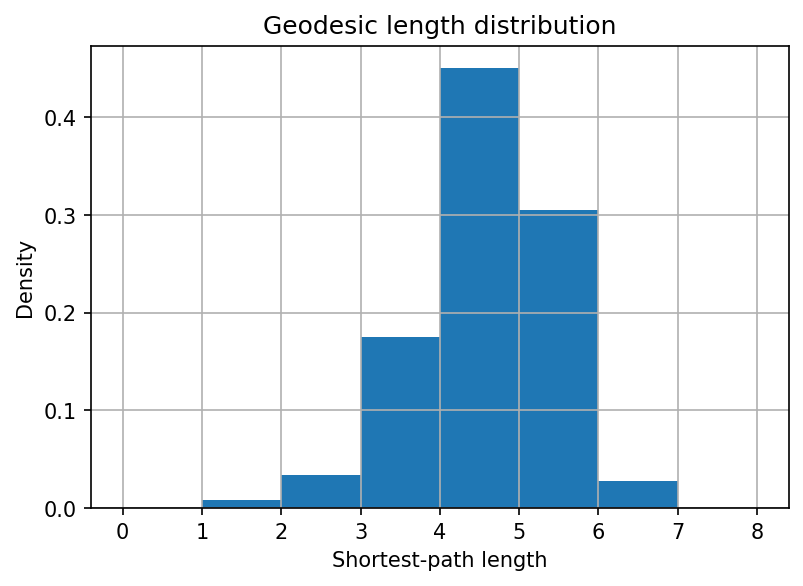

In [25]:
# Six-degrees-style distances in the small-world regime
print("Small-world (β=0.1):")
path_length_hist(Gs["Small-world (β=0.1)"], rng=rng)
print("Lattice-like (β=0):")
path_length_hist(Gs["Lattice-like (β=0)"], rng=rng)
print("Random-like (β=1):")
path_length_hist(Gs["Random-like (β=1)"], rng=rng)
print("Erdős-Rényi (p=0.024):")
path_length_hist(Gs["Erdős-Rényi (p=0.024)"], rng=rng)

### 5.4. Your Turn

Implement a contagion model of your choice, experiment with parameters, and visualize the results. We studied how changes in probability \(p\) (for IC) or threshold distributions (for WTM) affect the spread dynamics on different network structures. Now, try graph density or clustering (keep the \(p\) and threshold distributions constant, also control for average degree) and see how that shapes contagion.

## 6. How Structure Shapes Cascades

We examine how **degree heterogeneity** (ER vs BA) and **clustering/shortcuts** (WS with rewiring \(\beta\)) alter cascade sizes under IC and WTM.

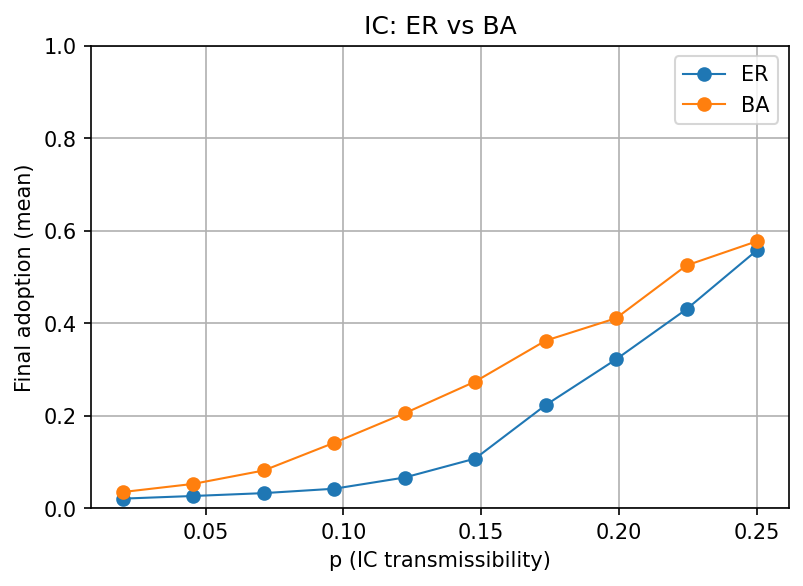

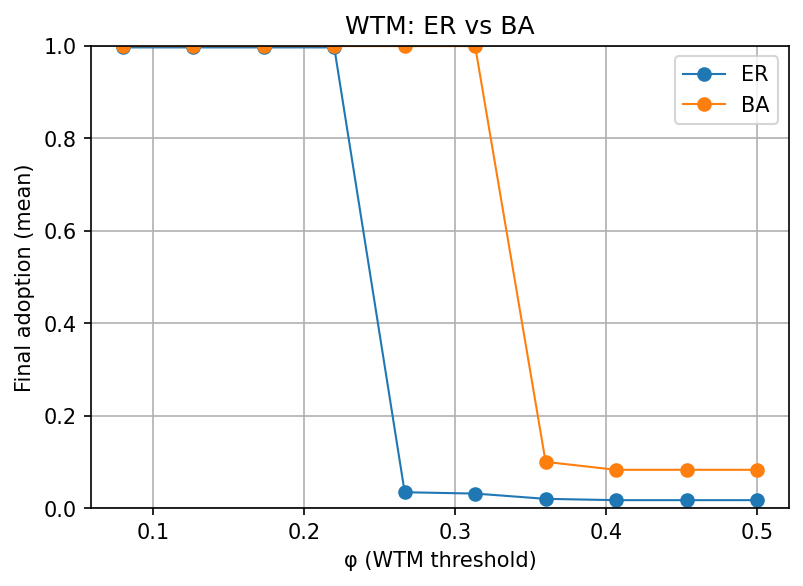

In [29]:

def make_graph(kind: str = "ER", n: int = 400, avg_k: float = 6, beta: float = 0.1, rng=None) -> nx.Graph:
    rng = rng or np.random.default_rng()
    if kind.upper() == "ER":
        p = avg_k/(n-1); return nx.erdos_renyi_graph(n, p, seed=rng)
    if kind.upper() == "WS":
        k = int(round(avg_k)); k += (k%2); return nx.watts_strogatz_graph(n, k, beta, seed=rng)
    if kind.upper() == "BA":
        m = max(1, int(round(avg_k/2))); return nx.barabasi_albert_graph(n, m, seed=rng)
    raise ValueError

def sweep_ic(G, seeds, ps, runs=10, rng=None):
    rng = rng or np.random.default_rng()
    rows = []
    for p in ps:
        for r in range(runs):
            res = simulate_ic(G, seeds, p=p, rng=rng)
            rows.append(dict(p=p, frac=len(res.adopted)/G.number_of_nodes()))
    return pd.DataFrame(rows)

def sweep_wtm(G, seeds, phis, runs=1, rng=None):
    rng = rng or np.random.default_rng()
    rows = []
    for phi in phis:
        for r in range(runs):
            res = simulate_wtm(G, seeds, phi=phi, rng=rng)
            rows.append(dict(phi=phi, frac=len(res.adopted)/G.number_of_nodes()))
    return pd.DataFrame(rows)

G_er = make_graph("ER", n=350, avg_k=6, rng=rng)
G_ba = make_graph("BA", n=350, avg_k=6, rng=rng)
seeds_er = choose_seeds(G_er, 5, method="degree", rng=rng)
seeds_ba = choose_seeds(G_ba, 5, method="degree", rng=rng)

ps   = np.linspace(0.02, 0.25, 10)
phis = np.linspace(0.08, 0.5, 10)

df_er_ic = sweep_ic(G_er, seeds_er, ps, runs=6, rng=rng)
df_ba_ic = sweep_ic(G_ba, seeds_ba, ps, runs=6, rng=rng)
df_er_wt = sweep_wtm(G_er, seeds_er, phis, runs=1, rng=rng)
df_ba_wt = sweep_wtm(G_ba, seeds_ba, phis, runs=1, rng=rng)

plt.plot(df_er_ic.groupby("p")["frac"].mean(), marker="o", lw=1, label="ER")
plt.plot(df_ba_ic.groupby("p")["frac"].mean(), marker="o", lw=1, label="BA")
plt.xlabel("p (IC transmissibility)"); plt.ylabel("Final adoption (mean)")
plt.ylim(0,1); plt.title("IC: ER vs BA"); plt.legend(); plt.show()

plt.plot(df_er_wt.groupby("phi")["frac"].mean(), marker="o", lw=1, label="ER")
plt.plot(df_ba_wt.groupby("phi")["frac"].mean(), marker="o", lw=1, label="BA")
plt.xlabel("φ (WTM threshold)"); plt.ylabel("Final adoption (mean)")
plt.ylim(0,1); plt.title("WTM: ER vs BA"); plt.legend(); plt.show()


### 6.1. Your Turn

**Your turn:**

Plot the following for both IC and WRM: 
1. **Degree heterogeneity** (ER vs BA).
2. **Clustering / small-world** (WS with varying rewiring \( \beta \)).
3. **Community structure** (e.g., planted partition; optional extension).

### 6.2 Your Turn

**Your turn:**
- For fixed \(n, \langle k \rangle\), compare IC vs WTM final adoption on ER vs BA across parameter sweeps.
- For WS, vary \( \beta \in [0,1] \) and show: IC global adoption typically rises with \( \beta \); WTM often shows a peak at *intermediate* \( \beta \) due to a balance of reinforcement and reach.

## 7. Thresholds, Heterogeneity, and Adoption Dynamics

**Outline:**
- Individual adoption thresholds
- Heterogeneous populations
- Impact on contagion dynamics

**Introduction:**
In real social systems, individuals differ in their willingness to adopt new ideas or behaviors. This section explores how varying thresholds and heterogeneity affect the spread of contagion, revealing richer and more realistic dynamics than uniform models.

**Motivation:**
Understanding threshold effects helps explain why some ideas fail to spread while others go viral, and how diversity in populations can stabilize or destabilize contagion.

Relevant Book:
The tipping point, by Malcolm Gladwell (2000).
https://www.amazon.com/Tipping-Point-Little-Things-Difference/dp/0316346624

## 8. Temporal Networks and Time-Varying Contagion

**Outline:**
- Networks with changing edges/nodes
- Contagion in dynamic environments
- Comparison to static networks

**Introduction:**
Many real-world networks evolve over time, with connections appearing and disappearing. This section introduces temporal networks and demonstrates how time-varying structure impacts contagion processes.

**Motivation:**
Studying temporal networks helps us understand phenomena like information bursts, viral trends, and the timing of interventions in dynamic systems.


## 9. Influence Maximization and Seeding Strategies

**Outline:**
- Selecting optimal seed nodes
- Greedy and heuristic algorithms
- Comparison of outcomes

**Introduction:**
Influence maximization seeks to identify the best nodes to initiate contagion for maximum spread. This section introduces key algorithms and compares their effectiveness in different networks.

**Motivation:**
Optimizing seed selection is vital for viral marketing, information campaigns, and epidemic control.


## 10. Competing Contagions and Interference

**Outline:**
- Multiple ideas/memes/behaviors
- Competition, suppression, coexistence
- Visualization of outcomes

**Introduction:**
In many settings, several ideas or behaviors compete for adoption. This section models competing contagions, showing how interference and suppression can shape the final outcome.

**Motivation:**
Understanding competition is crucial for marketing, public health, and information warfare, where multiple influences vie for attention.


## 11. Empirical Data Analysis

**Outline:**
- Load real-world network data
- Analyze and visualize contagion events
- Compare empirical and simulated results

**Introduction:**
Theory meets reality in this section, where we use actual social network data to study contagion. By comparing empirical and simulated outcomes, we gain insight into the strengths and limitations of our models.

**Motivation:**
Empirical analysis validates models and uncovers new patterns in real social systems.


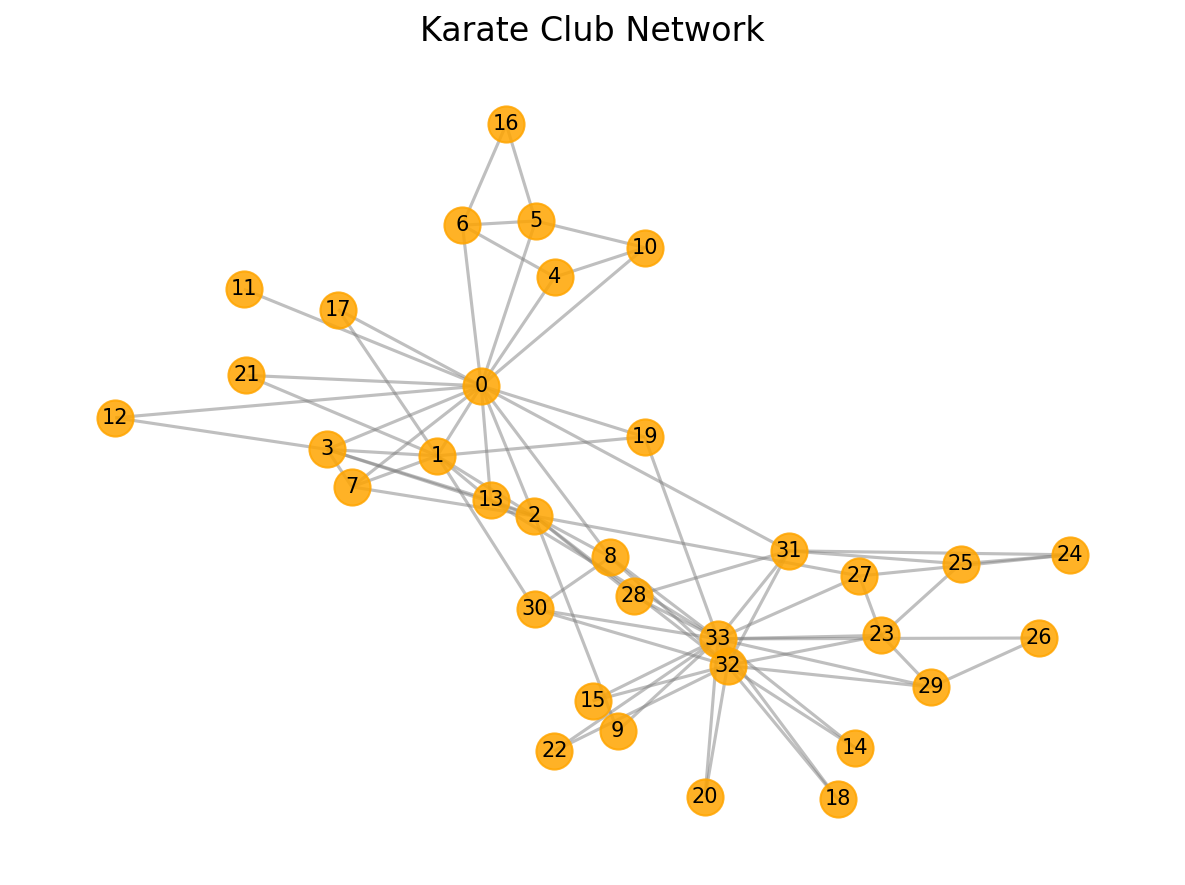

In [45]:
# Example: Load and visualize empirical network data
import networkx as nx
import matplotlib.pyplot as plt

# Load edge list from file (replace with actual path)
# G = nx.read_edgelist('data/empirical_network.edgelist')
G = nx.karate_club_graph()  # Example built-in dataset

pos = nx.spring_layout(G, seed=42)
# use ax
plt.figure(figsize=(8,6)) 
nx.draw_networkx_nodes(G, pos, node_color='orange', node_size=300, alpha=0.85)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1.5, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')
plt.title('Karate Club Network', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

### 11.1 Your Turn

Pick a dataset from networkrepository.com with nodes between 1k and 5k. Make sure it's structure is scale-free.

Load it, visualize its structure, and simulate both IC and WTM contagion processes. Compare the results to theoretical expectations and discuss any discrepancies or insights gained.

## 12. Other Extensions and Advanced Topics:


### 12.1 Contagion on Directed/Weighted Networks

**Outline:**
- Directionality and edge weights
- Impact on contagion
- Visualization and analysis

**Introduction:**
Not all connections are equal—some are stronger, and some have direction. This section explores how directed and weighted edges change the dynamics of contagion.

**Motivation:**
Accounting for direction and weight is essential for modeling influence, trust, and information flow in real networks.

### 12.2. Contagion Beyond Networks: Spatial, Agent-Based, and Hybrid Models

**Outline:**
- Spatial grids and agent-based models
- Hybrid approaches
- Comparison with network-based contagion

**Introduction:**
Contagion can also be modeled in spatial and agent-based frameworks, capturing local interactions and movement. This section introduces these models and compares them to network-based approaches.

**Motivation:**
Spatial and agent-based models provide deeper insight into phenomena like disease spread, crowd behavior, and innovation diffusion.


### 12.3. Advanced Visualization and Animation

**Outline:**
- Interactive widgets and animations
- Real-time and step-by-step visualizations
- GIF creation

**Introduction:**
Visualizing contagion dynamically brings models to life. This section introduces advanced visualization tools and techniques for interactive and animated exploration.

**Motivation:**
Animations and interactivity enhance understanding and engagement, making complex processes intuitive.


### 12.4. Social Contagion in LLMs

**Outline:**
- LLMs as agents in social networks
- Contagion of ideas, behaviors, and memes in LLM societies
- Simulation and analysis of propagation dynamics

**Introduction:**
Large Language Models (LLMs) can act as agents in digital societies, propagating information, behaviors, and even biases. This section explores how social contagion manifests in networks of LLMs, including emergent phenomena and feedback loops.

**Motivation:**
Understanding contagion in LLM agent societies is crucial for designing robust, ethical, and interpretable AI systems, and for anticipating unintended consequences in large-scale deployments.


### 12.5. Causal Identification: Contagion vs Homophily

**Outline:**
- Distinguishing contagion from homophily
- Experimental and statistical approaches
- Implications for inference and policy

**Introduction:**
Observed correlations in networks may arise from contagion (influence) or homophily (similarity). This section discusses methods to disentangle these effects and the challenges involved.

**Motivation:**
Causal identification is essential for valid inference and effective intervention in social systems.


### 12.6 Multiplex and Multilayer Networks

**Outline:**
- Multiple types of relationships (layers)
- Contagion across layers
- Layer interactions and synergy

**Introduction:**
Social contagion often spreads through different channels—friendship, work, online platforms. Multiplex networks model these layers, revealing how cross-layer interactions can accelerate or hinder contagion.

**Motivation:**
Understanding multiplexity helps design interventions and predict outcomes in systems with overlapping social structures.

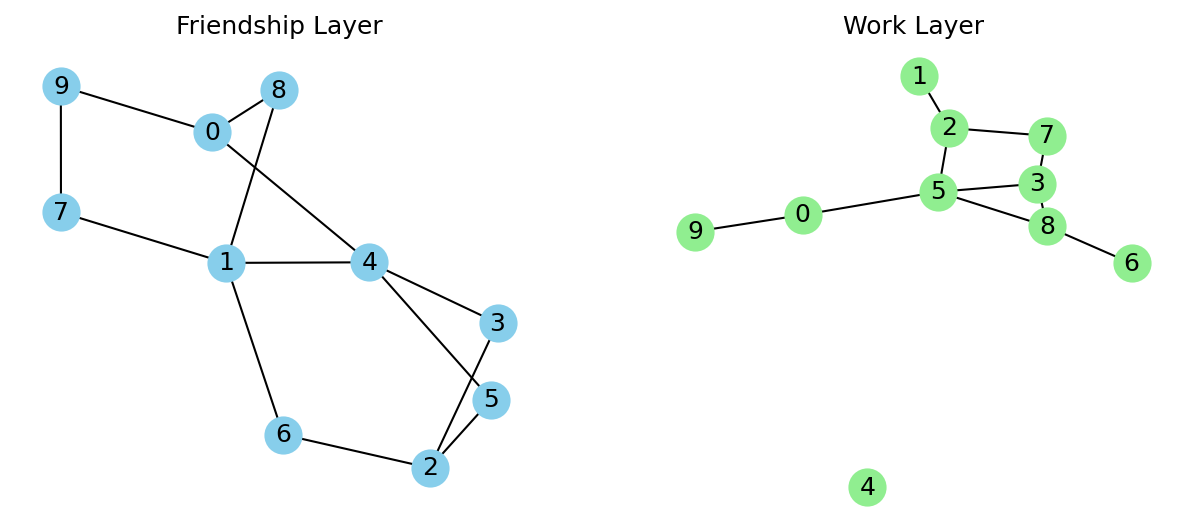

In [48]:
# Example: Multiplex network contagion
import networkx as nx
import matplotlib.pyplot as plt

# Layer 1: friendship
G1 = nx.erdos_renyi_graph(10, 0.3)
# Layer 2: work
G2 = nx.erdos_renyi_graph(10, 0.2)

# Visualize both layers
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
nx.draw(G1, ax=axes[0], with_labels=True, node_color='skyblue')
axes[0].set_title('Friendship Layer')
nx.draw(G2, ax=axes[1], with_labels=True, node_color='lightgreen')
axes[1].set_title('Work Layer')
plt.show()


## 13. References
- Milgram, S. (1967). *The small-world problem*. Psychology Today.  
- Watts, D. J., & Strogatz, S. H. (1998). *Collective dynamics of ‘small-world’ networks*. Nature.  
- Newman, M. E. J. (2002–2010). Random graphs & networks; percolation & epidemics on networks.  
- Pastor-Satorras, R., Castellano, C., Van Mieghem, P., & Vespignani, A. (2015). *Epidemic processes in complex networks*. Rev. Mod. Phys.  
- Kempe, D., Kleinberg, J., & Tardos, É. (2003). *Maximizing the spread of influence through a social network*. KDD.  
- Watts, D. J. (2002). *A simple model of global cascades on random networks*. PNAS.  
- Centola, D., & Macy, M. (2007). *Complex contagions and the weakness of long ties*. AJS.  
- Centola, D. (2010). *The spread of behavior in an online social network experiment*. Science.  
- Christakis, N. A., & Fowler, J. H. (2007–2013). Social contagion in health and behavior.
- Gleeson, J.P. & Cahalane, D.J. (2007); Gleeson (2008). *Cascades on random networks*. 
- Pastor-Satorras, R., Castellano, C., Van Mieghem, P., & Vespignani, A. (2015). *Epidemic processes in complex networks*. Rev. Mod. Phys.

## 14. Useful Links

- Network Repository: https://networkrepository.com/
- Six Degrees of Separation (Verbatism): https://www.youtube.com/watch?v=CYlon2tvywA